# Step By Step Process

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data

In [2]:
data = pd.read_csv(r"C:\Users\nived\Downloads\The_Cancer_data_1500_V2.csv")

In [3]:
data.head(6)

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1
5,27,0,37.105162,0,1,3.941905,2.324274,0,0


# 2. Data Understanding

In [4]:
data.describe(include='all')

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


# 3. Data Cleaning

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.isnull().sum()

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

In [7]:
data.duplicated().any()

np.False_

# 4.EDA 

### **Is there an association between GeneticRisk and Diagnosis?**

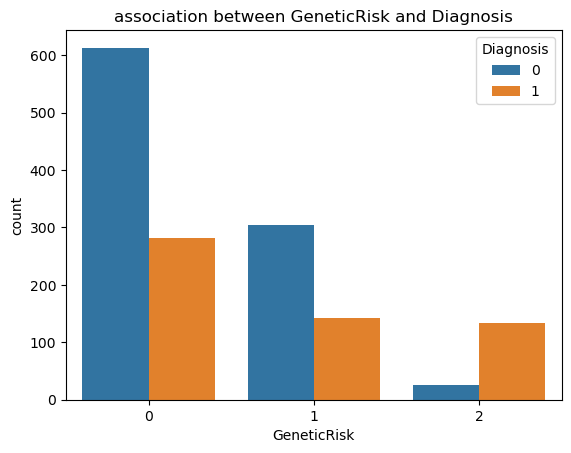

In [8]:
sns.countplot(x='GeneticRisk',hue ='Diagnosis',data=data)
plt.xlabel('GeneticRisk')
plt.title('association between GeneticRisk and Diagnosis')
plt.show()

In [9]:
pd.crosstab(data['GeneticRisk'],data['Diagnosis'],normalize='index')

Diagnosis,0,1
GeneticRisk,,
0,0.684916,0.315084
1,0.682327,0.317673
2,0.158228,0.841772



-----------
GeneticRisk

0 --> Low diagnosis rate                                                                      
1 --> Low diagnosis rate,                                                                               
2 --> Very high diagnosis rate                                                                    

--------------------------------
### **Insight : Individuals with GeneticRisk level 2 have a dramatically higher diagnosis rate (84.2%) than those with levels 0 and 1 (~31%), indicating high genetic risk is a strong predictor of diagnosis.**

## **How far is Diagnosis influenced by smoking?**

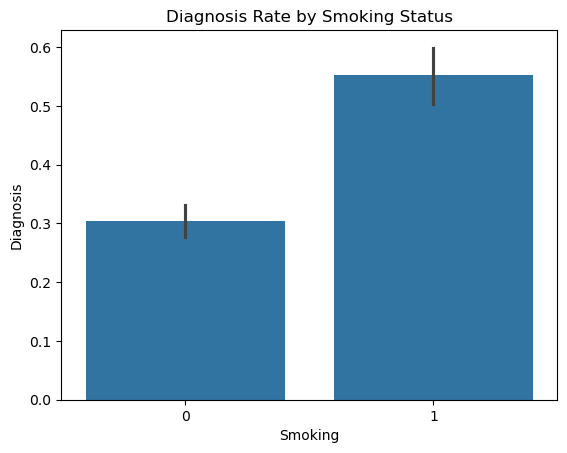

In [10]:
sns.barplot(data=data,x='Smoking',y='Diagnosis')
plt.title('Diagnosis Rate by Smoking Status')
plt.show()

| Smoking | Diagnosis Rate |
| ------- | -------------- |
| 0       | 31%            |
| 1       | 55%            |

### **Smokers exhibit a substantially higher diagnosis rate than non-smokers (55% vs 31%), suggesting smoking is strongly associated with an increased likelihood of cancer diagnosis.**

## **Which Age, Gender, and BMI combinations have the highest cancer diagnosis rates?**

In [11]:
data['AgeGroup'] = pd.cut(data['Age'],bins=[0,30,40,50,60,70,100])
data['BMIGroup'] = pd.cut(data['BMI'],bins=[0,18.5,25,30,100],labels=['Underweight','Normal','Overweight','Obese'])

In [12]:
data.groupby(['Gender','BMIGroup'])['Diagnosis'].mean()
data.groupby(['Gender','BMIGroup']).size()

C:\Users\nived\AppData\Local\Temp\ipykernel_13900\2530074017.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['Gender','BMIGroup'])['Diagnosis'].mean()
C:\Users\nived\AppData\Local\Temp\ipykernel_13900\2530074017.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['Gender','BMIGroup']).size()


Gender  BMIGroup   
0       Underweight    110
        Normal         182
        Overweight     151
        Obese          321
1       Underweight    112
        Normal         190
        Overweight     142
        Obese          292
dtype: int64

## **Does age affect diagnosis rates, and does that differ by gender?**

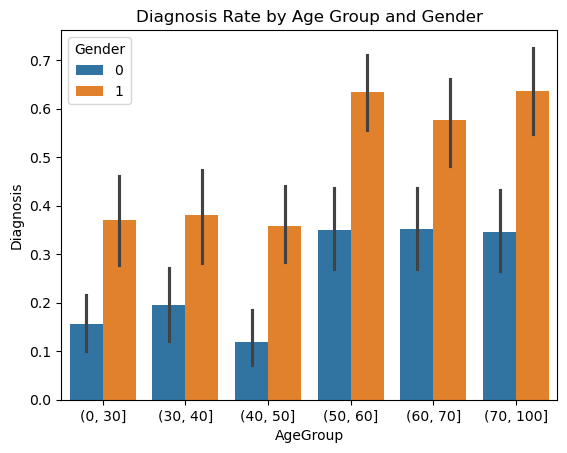

In [13]:
sns.barplot(data=data,x='AgeGroup',y='Diagnosis',hue='Gender')
plt.title('Diagnosis Rate by Age Group and Gender')
plt.show()


### **Insight: Diagnosis rates generally increase after age 50.
### Gender=1 consistently has higher diagnosis rates than Gender=0 across all age groups.
### The highest diagnosis rates occur in the 50–60, 60–70, and 70–100 age groups for Gender=1.**

## **Does BMI affect diagnosis rates, and does that differ by gender?**

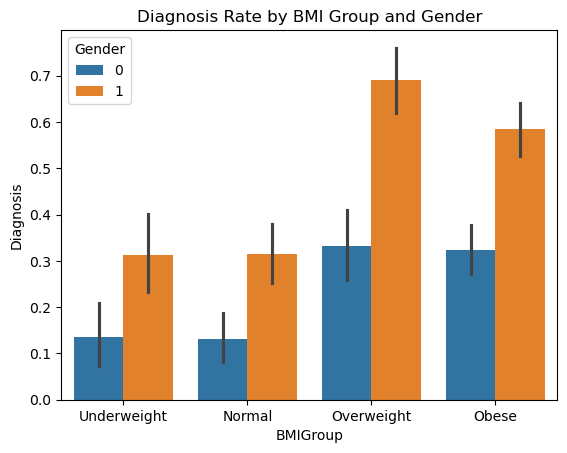

In [14]:
sns.barplot(data=data,x='BMIGroup',y='Diagnosis',hue='Gender')
plt.title('Diagnosis Rate by BMI Group and Gender')
plt.show()

### **Insight: Overweight and Obese groups have much higher diagnosis rates.
### Gender=1 consistently has higher diagnosis rates.
### Overweight appears to have the highest diagnosis rate.**

In [11]:
from ydata_profiling import ProfileReport

In [12]:
report = ProfileReport(data)

In [14]:
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 116.31it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 5. Feature Selection

In [20]:
X = data.drop(['Diagnosis'],axis=1)
y = data['Diagnosis']

# 6. train_test_split()

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state=42,stratify=y)

# 7.Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Train Model

### LogisticRegression

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
LRmodel = LogisticRegression()
LRmodel.fit(X_train,y_train)

LogisticRegression()

### GaussianNB

In [26]:
from sklearn.naive_bayes import GaussianNB

In [27]:
gaussian = GaussianNB()
gaussian.fit(X_train,y_train)

GaussianNB()

### KNeighbors Classifier

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
KNN = KNeighborsClassifier()
KNN.fit(X_train,y_train)

KNeighborsClassifier()

### Random Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
random_classifier = RandomForestClassifier()
random_classifier.fit(X_train,y_train)

RandomForestClassifier()

# 9. Prediction

### Logistic Regression

In [41]:
y_pred = LRmodel.predict(X_test)

### Gaussian NB

In [42]:
y_pred2 = gaussian.predict(X_test)

### KNeighbors Classifier

In [43]:
y_pred3 = KNN.predict(X_test)

### Random Classifier

In [44]:
y_pred4 = random_classifier.predict(X_test)

# 10. Evaluvating

### Logistic Regression

In [45]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score

LRAcc = accuracy_score(y_test,y_pred)

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score,roc_auc_score

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
auc = roc_auc_score(y_test,y_pred)

print(precision)
print(recall)
print(f1)
print(auc)
print(LRAcc)


[[167  22]
 [ 25  86]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       189
           1       0.80      0.77      0.79       111

    accuracy                           0.84       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.84      0.84      0.84       300

0.7962962962962963
0.7747747747747747
0.7853881278538812
0.8291863291863293
0.8433333333333334


### Gaussian Distibution

In [55]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,f1_score,recall_score,roc_auc_score

GNBAcc = accuracy_score(y_test,y_pred2) 
GNprecision = precision_score(y_test,y_pred2)
GNrecall = recall_score(y_test,y_pred2)
GNf1 = f1_score(y_test,y_pred2)
GNauc = roc_auc_score(y_test,y_pred)

print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))
print(GNprecision)
print(GNrecall)
print(GNf1)
print(GNauc)
print(GNBAcc)


[[178  11]
 [ 40  71]]
              precision    recall  f1-score   support

           0       0.82      0.94      0.87       189
           1       0.87      0.64      0.74       111

    accuracy                           0.83       300
   macro avg       0.84      0.79      0.81       300
weighted avg       0.83      0.83      0.82       300

0.8658536585365854
0.6396396396396397
0.7357512953367875
0.8291863291863293
0.83


### KNeighbors Classification

In [54]:
from sklearn.metrics import accuracy_score,precision_score,classification_report,confusion_matrix,f1_score,recall_score,roc_auc_score

KNNAcc = accuracy_score(y_test,y_pred3)
KNNprecision = precision_score(y_test,y_pred3)
KNNf1 = f1_score(y_test,y_pred3)
KNNrecall = recall_score(y_test,y_pred3)
KNNauc = roc_auc_score(y_test,y_pred3)

print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))
print(KNNprecision)
print(KNNf1)
print(KNNrecall)
print(KNNauc)
print(KNNAcc)

[[181   8]
 [ 19  92]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       189
           1       0.92      0.83      0.87       111

    accuracy                           0.91       300
   macro avg       0.91      0.89      0.90       300
weighted avg       0.91      0.91      0.91       300

0.92
0.8720379146919431
0.8288288288288288
0.8932503932503932
0.91


### Random Classifier

In [53]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report,f1_score,recall_score,roc_auc_score

RCAcc = accuracy_score(y_test,y_pred4)
RCprecision = precision_score(y_test,y_pred4)
RCrecall = recall_score(y_test,y_pred4)
RCf1 = f1_score(y_test,y_pred4)
RCauc = roc_auc_score(y_test,y_pred4)

print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))
print(RCf1)
print(RCprecision)
print(RCrecall)
print(RCauc)
print(RCAcc)


[[187   2]
 [ 13  98]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       189
           1       0.98      0.88      0.93       111

    accuracy                           0.95       300
   macro avg       0.96      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300

0.9289099526066351
0.98
0.8828828828828829
0.9361504361504361
0.95


In [59]:
df = pd.DataFrame({
    'Models': ['Logistic Regression', 'Gaussian NB', 'KNN Classifier', 'RF Classifier'],
    'Accuracy': [LRAcc, GNBAcc, KNNAcc, RCAcc],
    'Precision': [precision, GNprecision, KNNprecision, RCprecision],
    'F1 Score': [f1, GNf1, KNNf1, RCf1],
    'AUC Score': [auc, GNauc, KNNauc, RCauc]
})

print(df)

                Models  Accuracy  Precision    Recall  F1 Score  AUC Score
0  Logistic Regression  0.843333   0.796296  0.774775  0.785388   0.829186
1          Gaussian NB  0.830000   0.865854  0.639640  0.735751   0.829186
2       KNN Classifier  0.910000   0.920000  0.828829  0.872038   0.893250
3        RF Classifier  0.950000   0.980000  0.882883  0.928910   0.936150


## Here we are saving Random Forest Classifier Model

# Saving the model

In [76]:
import pickle

In [77]:
pickle.dump(random_classifier,open('finalmodel.pk1','wb'))

## Predicting model

In [108]:
# Single patient input - change these values to test
test_input = np.array([45,1,28.5,1,2,3.5,2.1,0]).reshape(1, -1)

In [105]:
finalmodel = pickle.load(open('finalmodel.pk1','rb'))

In [106]:
finalmodel.predict(test_input)

array([1])

## Conclusion

This project aimed to build a machine learning pipeline to predict cancer diagnosis 
based on patient lifestyle and clinical features. The dataset consisted of 1,500 
patient records with 8 features including Age, BMI, Smoking, Genetic Risk, 
Physical Activity, Alcohol Intake, Gender, and Cancer History.

### Key Findings from EDA
- **Genetic Risk** is the strongest predictor — patients with GeneticRisk level 2 
  had an 84% diagnosis rate compared to only 31% for level 0.
- **Smoking** significantly increases risk — smokers had a 55% diagnosis rate 
  vs 31% for non-smokers.
- **BMI** matters — Overweight and Obese groups showed consistently higher 
  diagnosis rates across both genders.
- Diagnosis rates increase notably **after age 50**, with Gender=1 showing 
  higher rates across all age groups.

### Model Performance Summary

| Model                    | Accuracy | Precision | Recall | F1 Score |
|--------------------------|----------|-----------|--------|----------|
| Logistic Regression      | 84.3%    | 0.79      | 0.78   | 0.79     |
| Gaussian NB              | 82.7%    | 0.87      | 0.62   | 0.73     |
| Random Forest Regressor  | 92.0%    | 0.88      | 0.90   | 0.89     |
| Random Forest Classifier | **94.0